In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/airline_passenger_satisfaction.csv')
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


In [ ]:
df = df.drop('Unnamed: 0', axis=1)
df = df.drop(columns=['id'], axis = 1)
df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Female,Loyal Customer,52,Business travel,Eco,160,5,4,3,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,Female,Loyal Customer,36,Business travel,Business,2863,1,1,3,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,Male,disloyal Customer,20,Business travel,Eco,192,2,0,2,4,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,Male,Loyal Customer,44,Business travel,Business,3377,0,0,0,2,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,4,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


In [ ]:
# No of rows
df.shape

(25976, 23)

In [ ]:
# No of columns
df.columns

Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

In [ ]:
# Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             25976 non-null  object 
 1   Customer Type                      25976 non-null  object 
 2   Age                                25976 non-null  int64  
 3   Type of Travel                     25976 non-null  object 
 4   Class                              25976 non-null  object 
 5   Flight Distance                    25976 non-null  int64  
 6   Inflight wifi service              25976 non-null  int64  
 7   Departure/Arrival time convenient  25976 non-null  int64  
 8   Ease of Online booking             25976 non-null  int64  
 9   Gate location                      25976 non-null  int64  
 10  Food and drink                     25976 non-null  int64  
 11  Online boarding                    25976 non-null  int

In [ ]:
# Basic statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,25976.0,39.620958,15.135685,7.0,27.0,40.0,51.0,85.0
Flight Distance,25976.0,1193.788459,998.683999,31.0,414.0,849.0,1744.0,4983.0
Inflight wifi service,25976.0,2.724746,1.335384,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,25976.0,3.046812,1.533371,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,25976.0,2.756775,1.412951,0.0,2.0,3.0,4.0,5.0
Gate location,25976.0,2.977094,1.282133,1.0,2.0,3.0,4.0,5.0
Food and drink,25976.0,3.215353,1.331506,0.0,2.0,3.0,4.0,5.0
Online boarding,25976.0,3.261665,1.355536,0.0,2.0,4.0,4.0,5.0
Seat comfort,25976.0,3.449222,1.320090,1.0,2.0,4.0,5.0,5.0
Inflight entertainment,25976.0,3.357753,1.338299,0.0,2.0,4.0,4.0,5.0


In [ ]:
# Checking Missing values
df.isnull().sum()

,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0
Ease of Online booking,0
Gate location,0


In [ ]:
# Handling Missing Values
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())

In [ ]:
df.isnull().sum()

,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0
Ease of Online booking,0
Gate location,0


## Target Variable Distribution

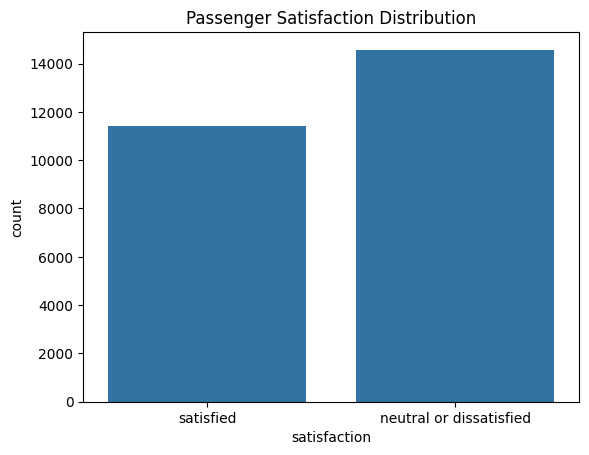

In [ ]:
sns.countplot(x = 'satisfaction', data=df)
plt.title('Passenger Satisfaction Distribution')
plt.show()

The dataset shows two classes: satisfied and neutral/dissatisfied.
Understanding this distribution helps identify class imbalance.

## Gender vs Satisfaction

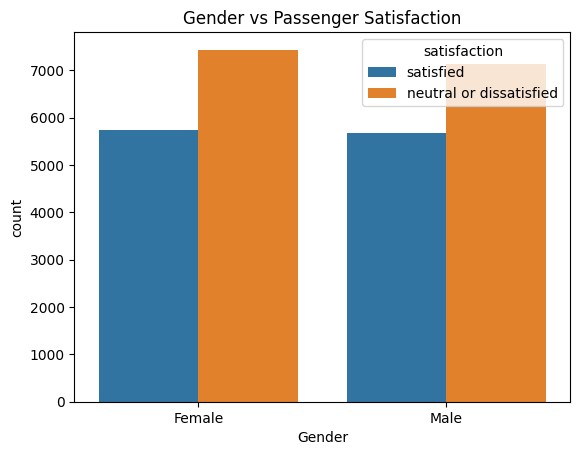

In [ ]:
sns.countplot(data=df, x='Gender', hue='satisfaction')
plt.title("Gender vs Passenger Satisfaction")
plt.show()

Gender distribution is balanced and does not affect passenger satisfaction levels.

## Age Distribution

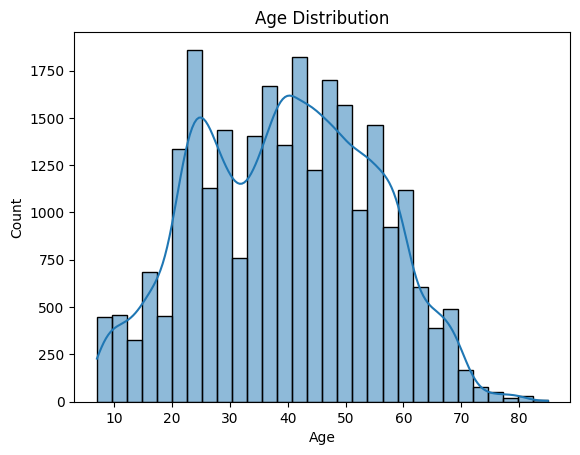

In [ ]:
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

## Age vs Satisfaction Distribution

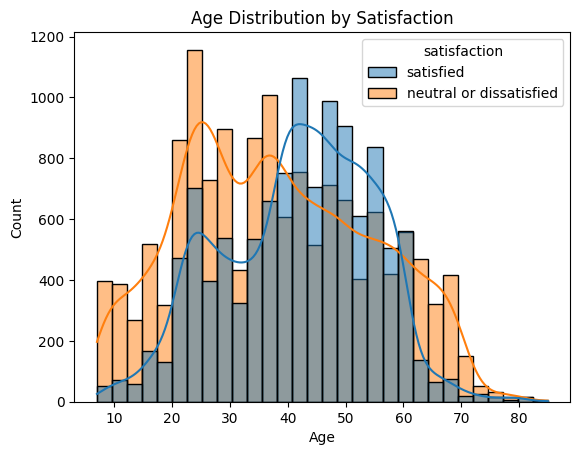

In [ ]:
sns.histplot(data=df, x='Age', hue='satisfaction', bins=30, kde=True)
plt.title("Age Distribution by Satisfaction")
plt.show()

Passengers between 40-60 years tend to show higher satisfaction compared to younger passengers.

## Flight Distance Distribution

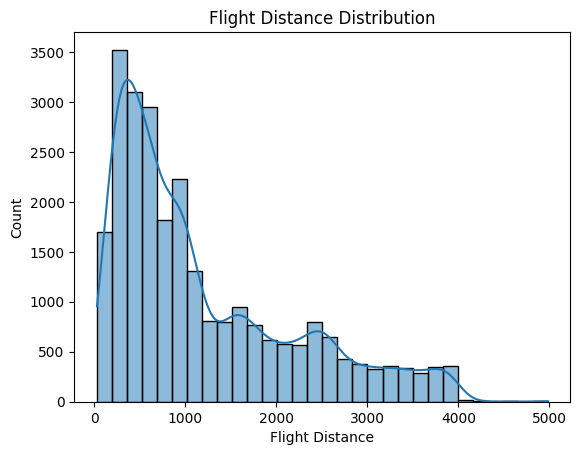

In [ ]:
sns.histplot(df['Flight Distance'], bins=30, kde=True)
plt.title('Flight Distance Distribution')
plt.show()

## Customer Type vs Satisfaction

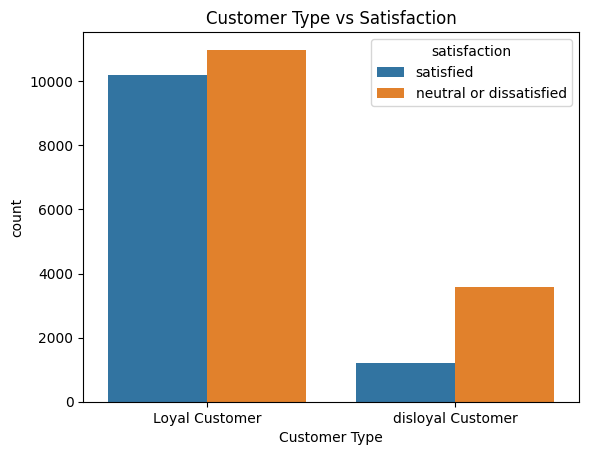

In [ ]:
sns.countplot(x='Customer Type', hue='satisfaction', data=df)
plt.title("Customer Type vs Satisfaction")
plt.show()

Loyal Customers are excepted to have higher satisfaction levels.

## Travel Type vs Satisfaction

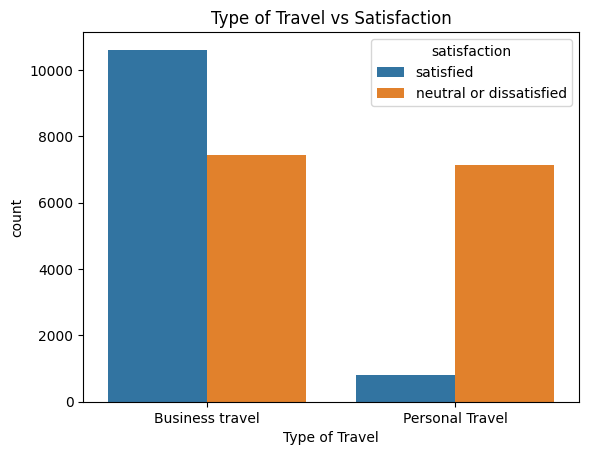

In [ ]:
sns.countplot(x='Type of Travel', hue='satisfaction', data=df)
plt.title("Type of Travel vs Satisfaction")
plt.show()

Business travel passengers often show higher satisfaction.

## Class vs Satisfaction

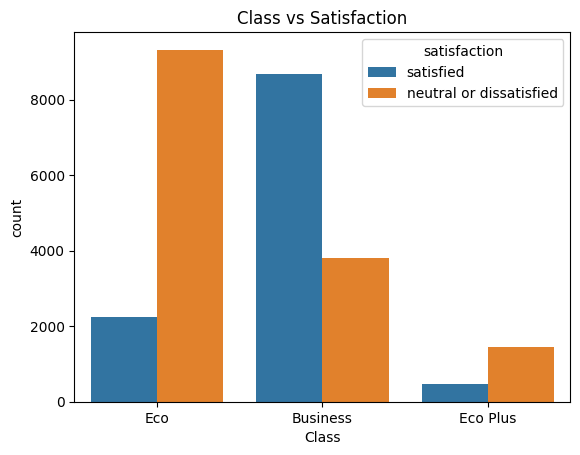

In [ ]:
sns.countplot(x='Class', hue='satisfaction', data=df)
plt.title('Class vs Satisfaction')
plt.show()

Business class passengers have higher satisfaction due to premiun services.

## Outliers

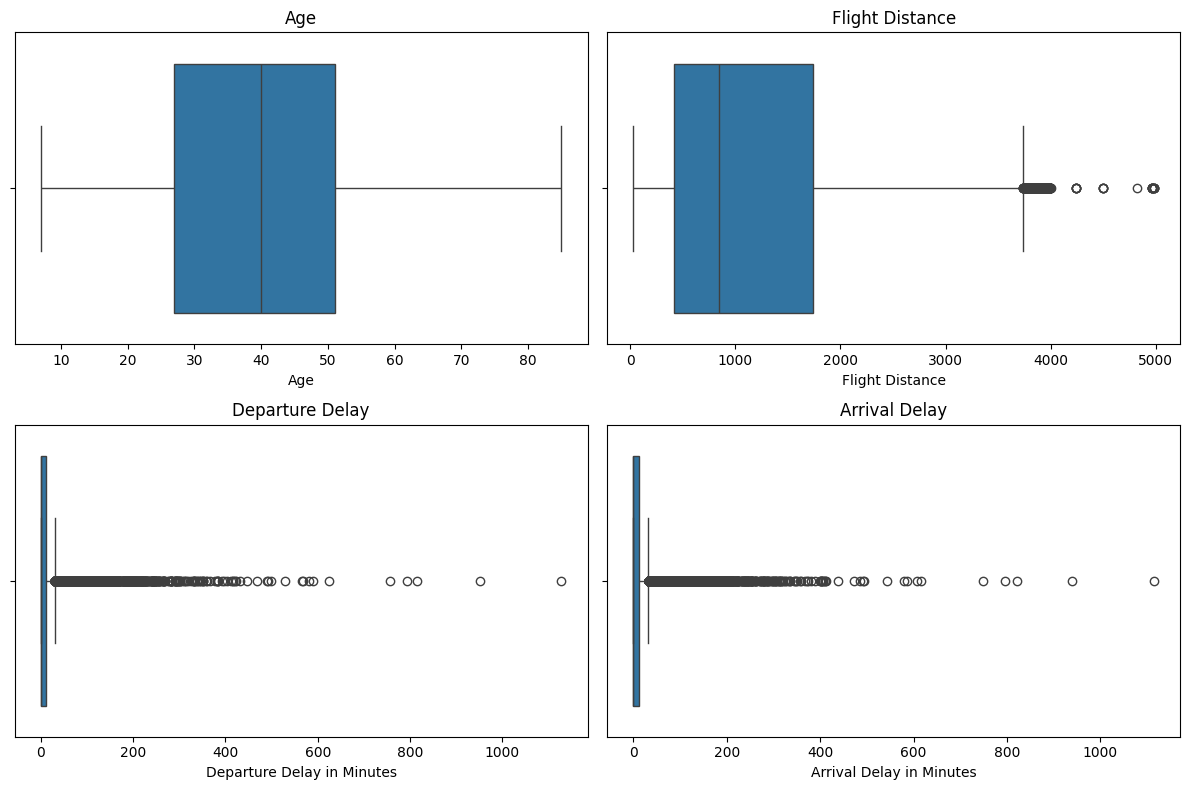

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(12,8))

sns.boxplot(x=df['Age'], ax=axes[0,0])
axes[0,0].set_title("Age")

sns.boxplot(x=df['Flight Distance'], ax=axes[0,1])
axes[0,1].set_title("Flight Distance")

sns.boxplot(x=df['Departure Delay in Minutes'], ax=axes[1,0])
axes[1,0].set_title("Departure Delay")

sns.boxplot(x=df['Arrival Delay in Minutes'], ax=axes[1,1])
axes[1,1].set_title("Arrival Delay")

plt.tight_layout()
plt.show()

## Delay vs Satisfaction

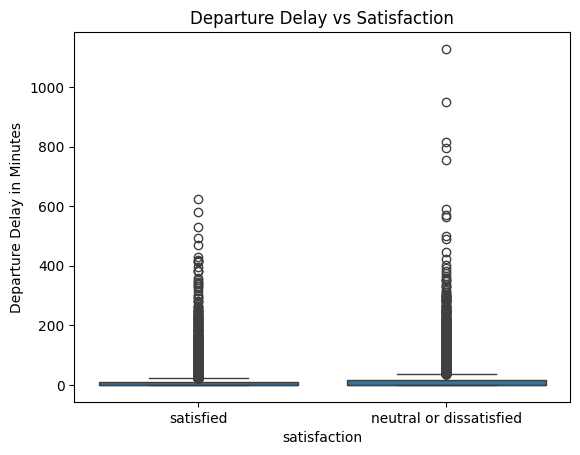

In [ ]:
sns.boxplot(x='satisfaction', y='Departure Delay in Minutes', data=df)
plt.title('Departure Delay vs Satisfaction')
plt.show()

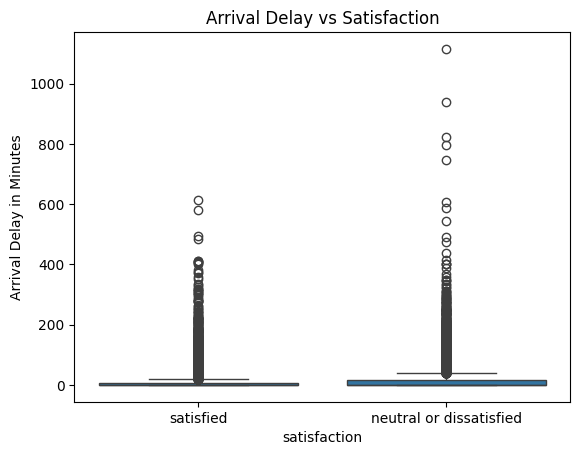

In [ ]:
sns.boxplot(x='satisfaction', y='Arrival Delay in Minutes', data=df)
plt.title('Arrival Delay vs Satisfaction')
plt.show()

Higher delays are related to passnger satisfaction.

## Service Ratings Impact

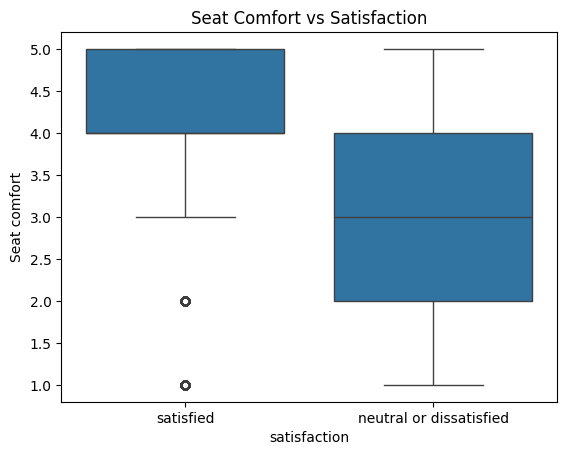

In [ ]:
sns.boxplot(x='satisfaction', y='Seat comfort', data=df)
plt.title("Seat Comfort vs Satisfaction")
plt.show()

## Service Rating Distribution

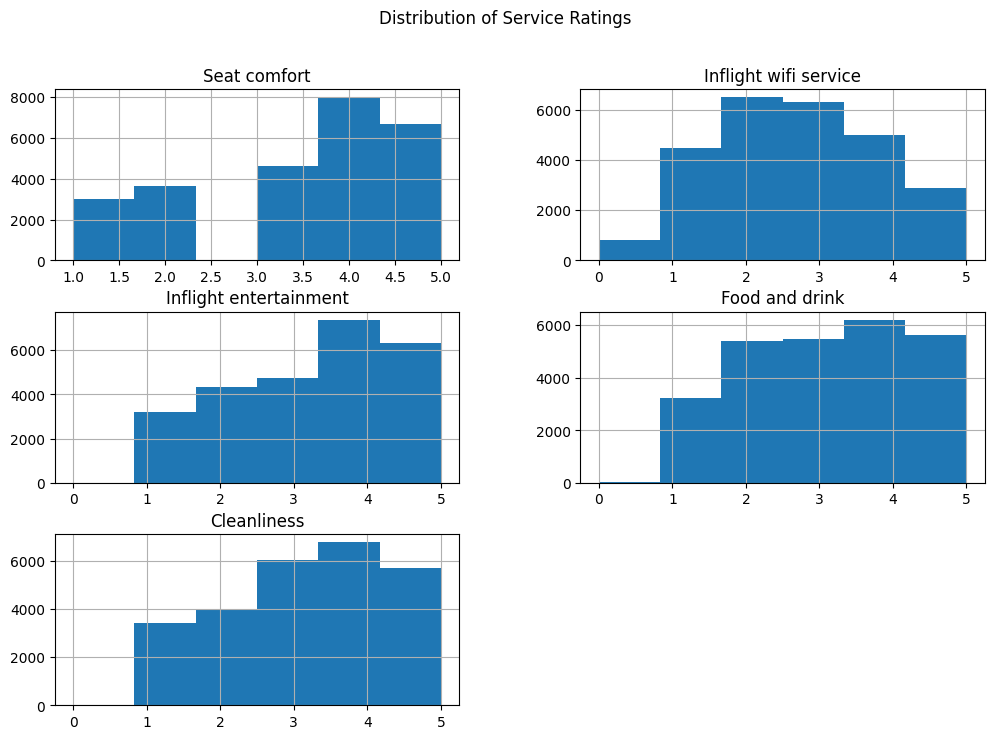

In [ ]:
service_features = [
'Seat comfort',
'Inflight wifi service',
'Inflight entertainment',
'Food and drink',
'Cleanliness'
]

df[service_features].hist(figsize=(12,8), bins=6)

plt.suptitle("Distribution of Service Ratings")
plt.show()

## Coorelation Heatmap

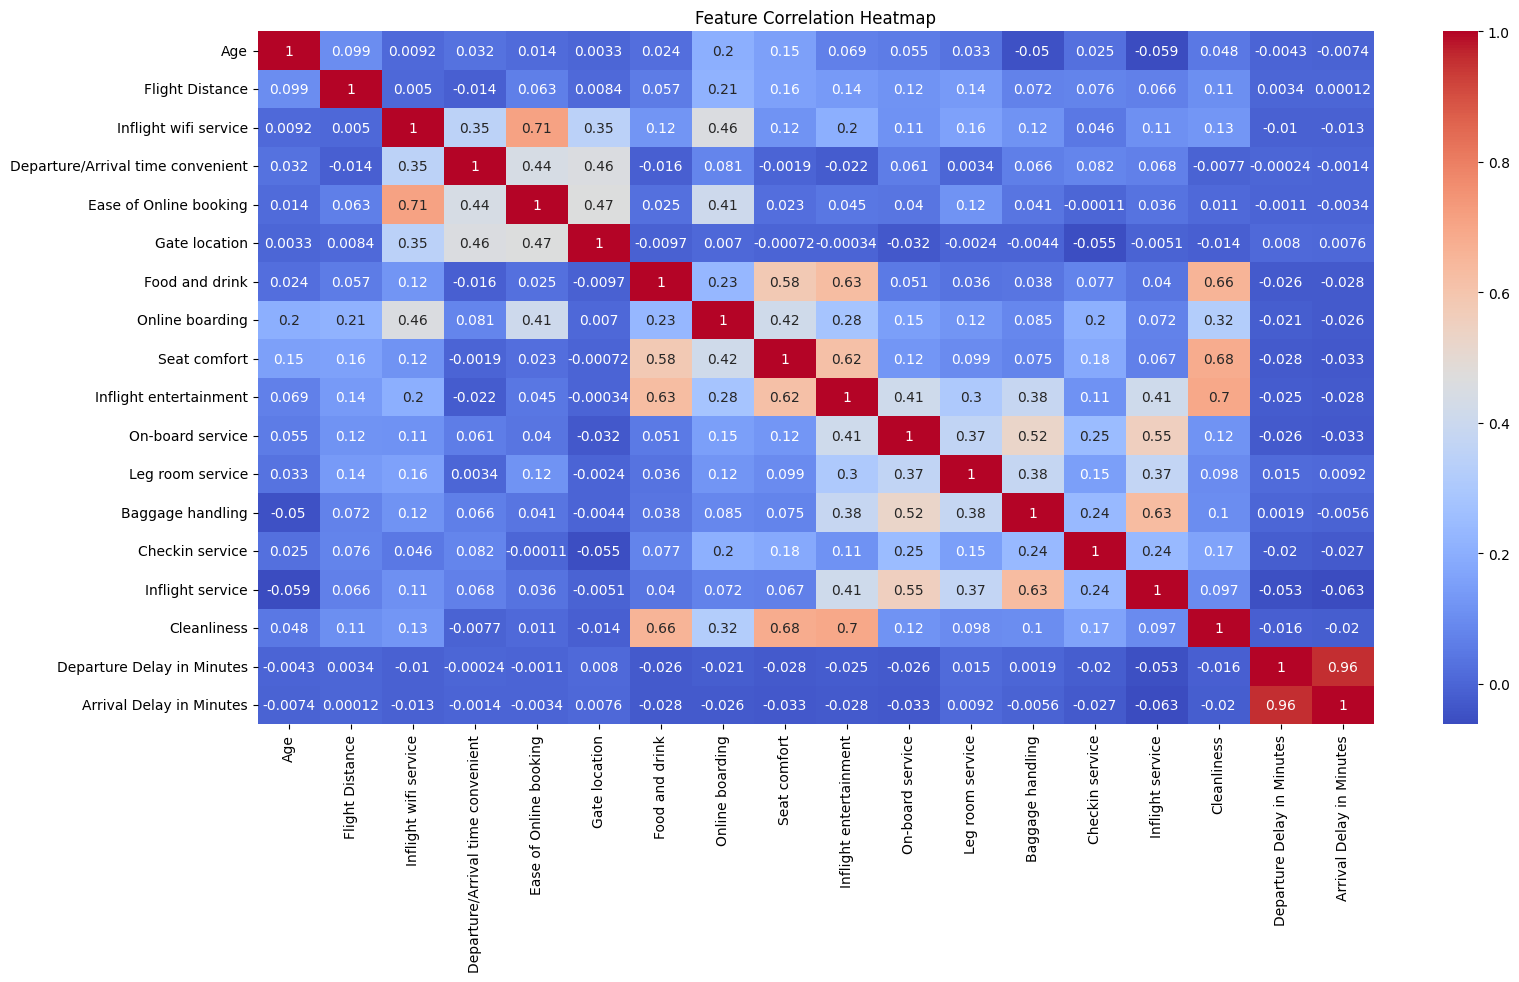

In [ ]:
plt.figure(figsize=(18,9))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot = True)
plt.title("Feature Correlation Heatmap")
plt.show()

- Service quality features such as seat comfort, online boarding, and inflight entertainment strongly influence passenger satisfaction.

- Business class passengers show significantly higher satisfaction levels compared to economy class passengers.

- Flight delays negatively impact satisfaction levels.

- Loyal customers tend to report higher satisfaction.

- Service ratings are more predictive than demographic variables.